In [49]:
import importlib
import eval_functions
importlib.reload(eval_functions)
from eval_functions import *
import pandas as pd
from enum import Enum
import numpy as n

from IPython.display import display
# make tables interactive
from itables import init_notebook_mode
import itables.options as opt
init_notebook_mode(all_interactive=True, connected=True)
opt.maxBytes=0

In [65]:
KOFOLA_VERSION="c729572"
KOFOLA_TACAS23="kofola-tacas23-tacas23"
KOFOLA_SIM_PRUNE="kofola-sim-prune-af70d5f"
KOFOLA_SUBS_TUP="kofola-subs-tup-c729572"
OLD_KOFOLA="kofola-raw-7b893f1"
KOFOLA_BREAK="kofola-break-afb44c1"
KOFOLA_RED="kofola-red-d0fc1c7"
KOFOLA_TELA="kofola-tela-d0fc1c7"
KOFOLA_TELA_RED="kofola-tela-red-d0fc1c7"
SPOT="spot-2.14.5"
SPOT_RED="spot-red-2.14.5"
KOFOLA="kofola-"+KOFOLA_VERSION
KOFOLA_CHECK="kofola-check-"+KOFOLA_VERSION
KOFOLA_SIM_PRUNE_CHECK="kofola-sim-prune-check-2286f10"
KOFOLA_SUBS_TUP_CHECK="kofola-subs-tup-check-afb44c1"
COLA="cola-cola"
RANKER="ranker-ranker"
SPOT_BA="spot-ba-2.14.2"
OWL="owl-owl-21.0"

KOFOLA_TELA_DNF="kofola-tela-dnf-ad55f7a"
KOFOLA_TELA_DNF_CHECK="kofola-tela-dnf-check-ad55f7a"

KOFOLA_TELA_INDUCTIVE="kofola-tela-inductive-44c3ea3"
KOFOLA_TELA_INDUCTIVE_OLD="kofola-tela-inductive-for-8fe1136"
KOFOLA_TELA_INDUCTIVE_CHECK="kofola-tela-inductive-check-44c3ea3"
KOFOLA_TELA_INDUCTIVE_SHB_SUBTREE="kofola-tela-inductive-shb-subtree-44c3ea3"
KOFOLA_TELA_INDUCTIVE_SHB_SUBTREE_CHECK="kofola-tela-inductive-shb-subtree-check-44c3ea3"
KOFOLA_TELA_INDUCTIVE_SHB_ROOT="kofola-tela-inductive-shb-root-44c3ea3"
KOFOLA_TELA_INDUCTIVE_SHB_ROOT_CHECK="kofola-tela-inductive-shb-root-check-44c3ea3"
KOFOLA_TELA_INDUCTIVE_FOR="kofola-tela-inductive-for-44c3ea3"
KOFOLA_TELA_INDUCTIVE_FOR_CHECK="kofola-tela-inductive-for-check-44c3ea3"

# Timeout (in seconds) 
TIMEOUT=120


TOOLS = list(dict.fromkeys([ # small hack so that we get list of unique values (i.e. a set, but also in the given order; see https://stackoverflow.com/questions/1653970/does-python-have-an-ordered-set)
    #KOFOLA_TELA_DNF,
    KOFOLA_TELA_INDUCTIVE,
    KOFOLA_TELA_INDUCTIVE_OLD,
    #KOFOLA_TELA_INDUCTIVE_OLD,
    # KOFOLA,
    KOFOLA_TELA_INDUCTIVE_SHB_SUBTREE,
    KOFOLA_TELA_INDUCTIVE_SHB_ROOT,
    KOFOLA_TELA_INDUCTIVE_FOR,
    # OLD_KOFOLA,
    #KOFOLA_BREAK,
    #KOFOLA_RED,
    #KOFOLA_TELA,
    #KOFOLA_TELA_RED,
    SPOT,
    # OWL,
    # SPOT_BA,
    SPOT_RED,
    # KOFOLA_TACAS23,
    #KOFOLA_SUBS_TUP,
    #KOFOLA_SIM_PRUNE,
    # COLA,
    # RANKER

    # you can add more tools here directly if needed
]))
TOOLS_CHECK = list(dict.fromkeys([
    #KOFOLA_CHECK,
    #KOFOLA_SUBS_TUP_CHECK
    #KOFOLA_SIM_PRUNE_CHECK
    #KOFOLA_TELA_DNF_CHECK,
    KOFOLA_TELA_INDUCTIVE_SHB_ROOT_CHECK,
    KOFOLA_TELA_INDUCTIVE_SHB_SUBTREE_CHECK,
    KOFOLA_TELA_INDUCTIVE_CHECK,
    KOFOLA_TELA_INDUCTIVE_FOR_CHECK
]))

BENCHES = [
  "advanced_automata_termination",
  "autohyper",
  "pecan",
  "s1s",
  "state_of_buchi",
  "seminator",
  "ldba4ltl",
]

BENCHES = [
  #"ltl_tela",
  "ltl_tela_elevator",
  "elevator_generalized_rabin_pair_tela",
  "random_ltl_elevators",
]


In [66]:
df_all = load_benches(BENCHES, TOOLS+TOOLS_CHECK, TIMEOUT) # last parameter is timeout
classification_df = parse_classifications_for_benchmarks(BENCHES)
# Join with main data
df_all = join_with_classification(df_all, classification_df)


## Evaluation

In [67]:

print(simple_table(df_all, TOOLS, BENCHES, separately=False))
print(simple_table(df_all, TOOLS, BENCHES, separately=True))

# of automata: 2693
----------------------------------------------------------------------------------------------------
tool                                         ✅    ❌       states    max-states    states-avg    states-med     time    time-avg    time-med    TO    ERR
-----------------------------------------  ----  ----  -----------  ------------  ------------  ------------  -------  ----------  ----------  ----  -----
kofola-tela-inductive-44c3ea3              2446   247   1312689.00     103380.00        536.67         21.00  3629.06        1.48        0.01   221     26
kofola-tela-inductive-for-8fe1136          2652    41   6437856.00     237725.00       2427.55         25.00  3073.45        1.16        0.01    15     26
kofola-tela-inductive-shb-subtree-44c3ea3  2451   242   1339994.00     103380.00        546.71         23.00  3065.88        1.25        0.01   216     26
kofola-tela-inductive-shb-root-44c3ea3     2467   226   1576427.00     103380.00        639.01         26.

In [72]:
TOOL_FOR_COMPARISON = KOFOLA_TELA_INDUCTIVE_FOR

### States

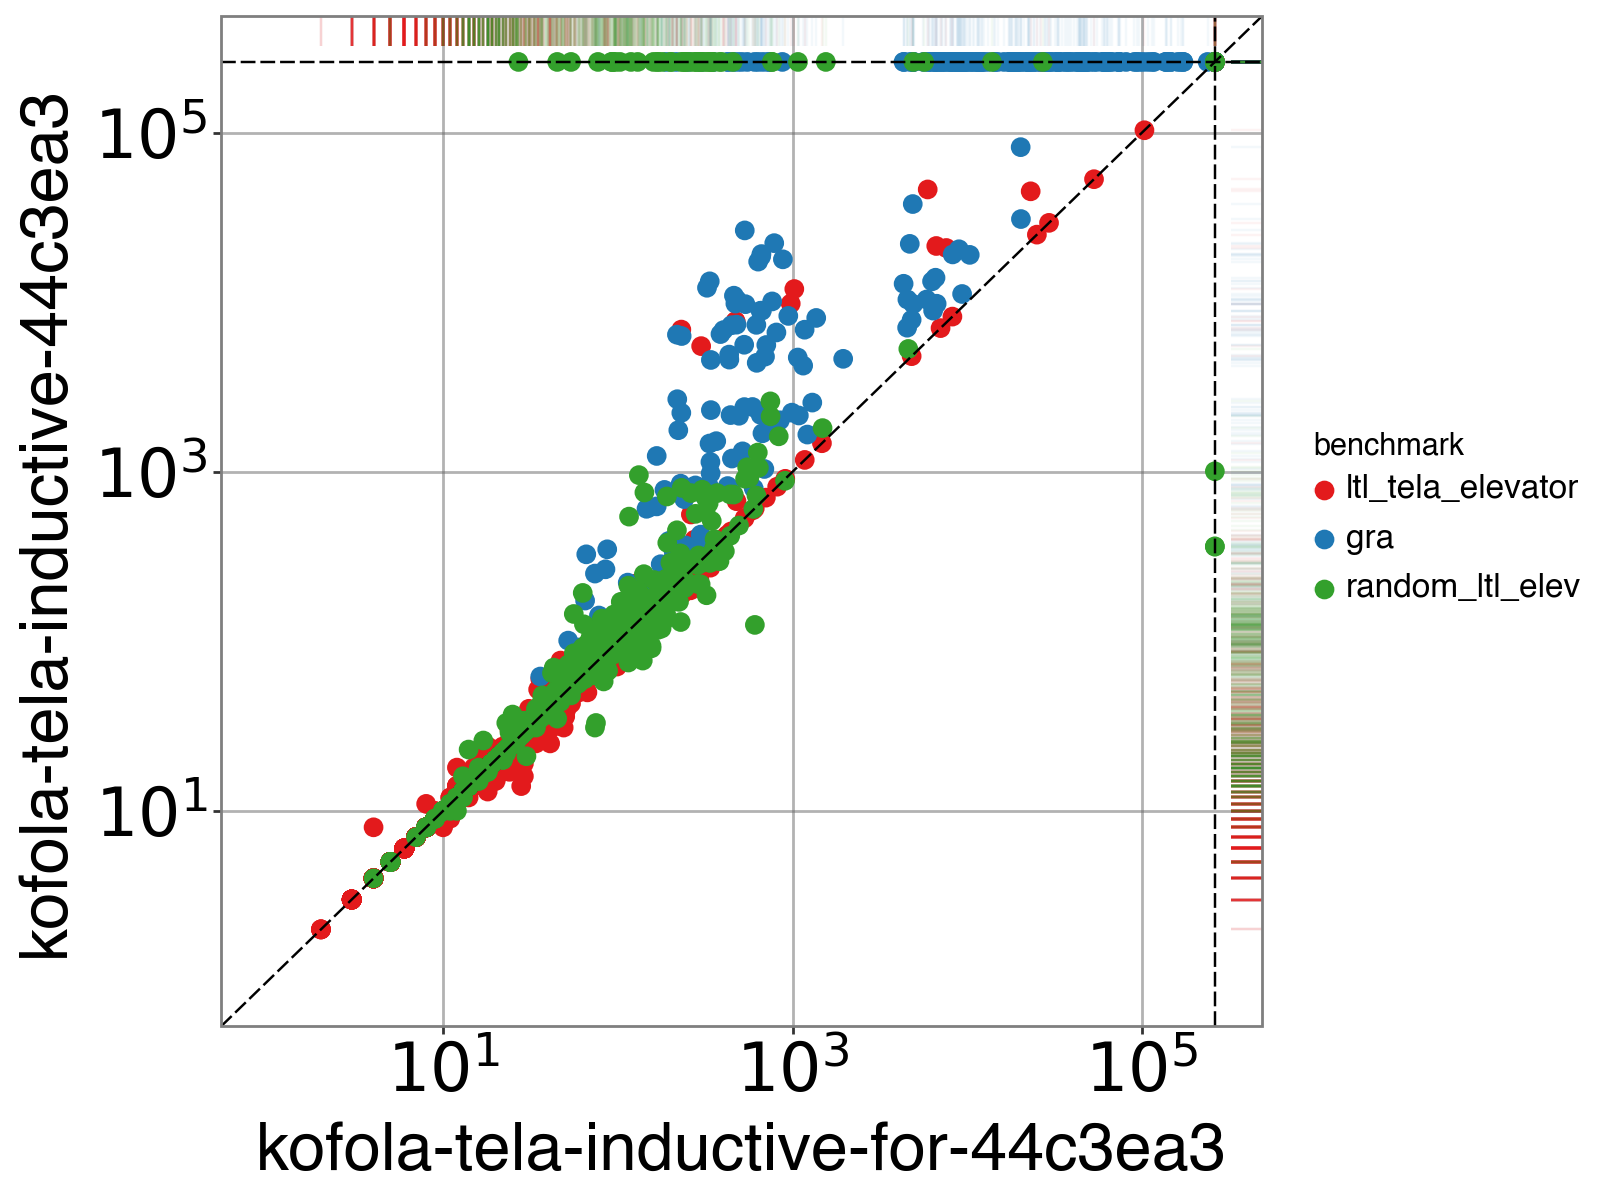

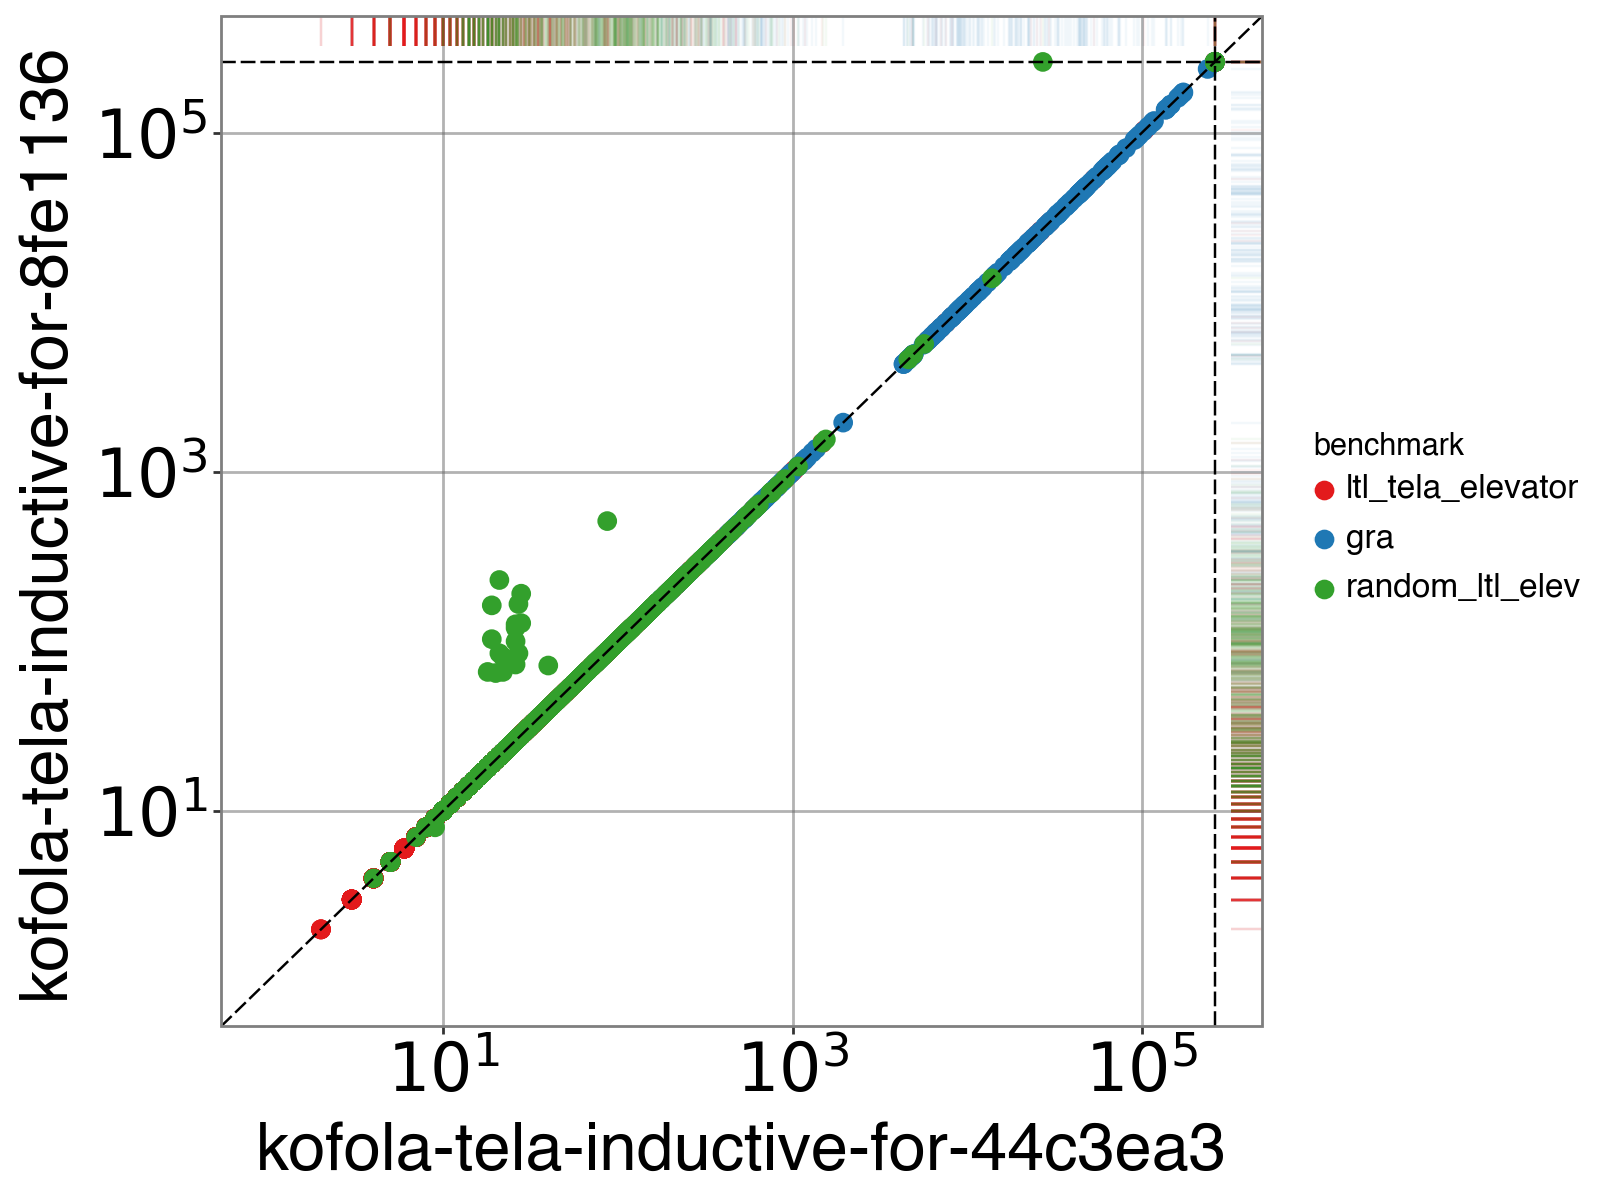

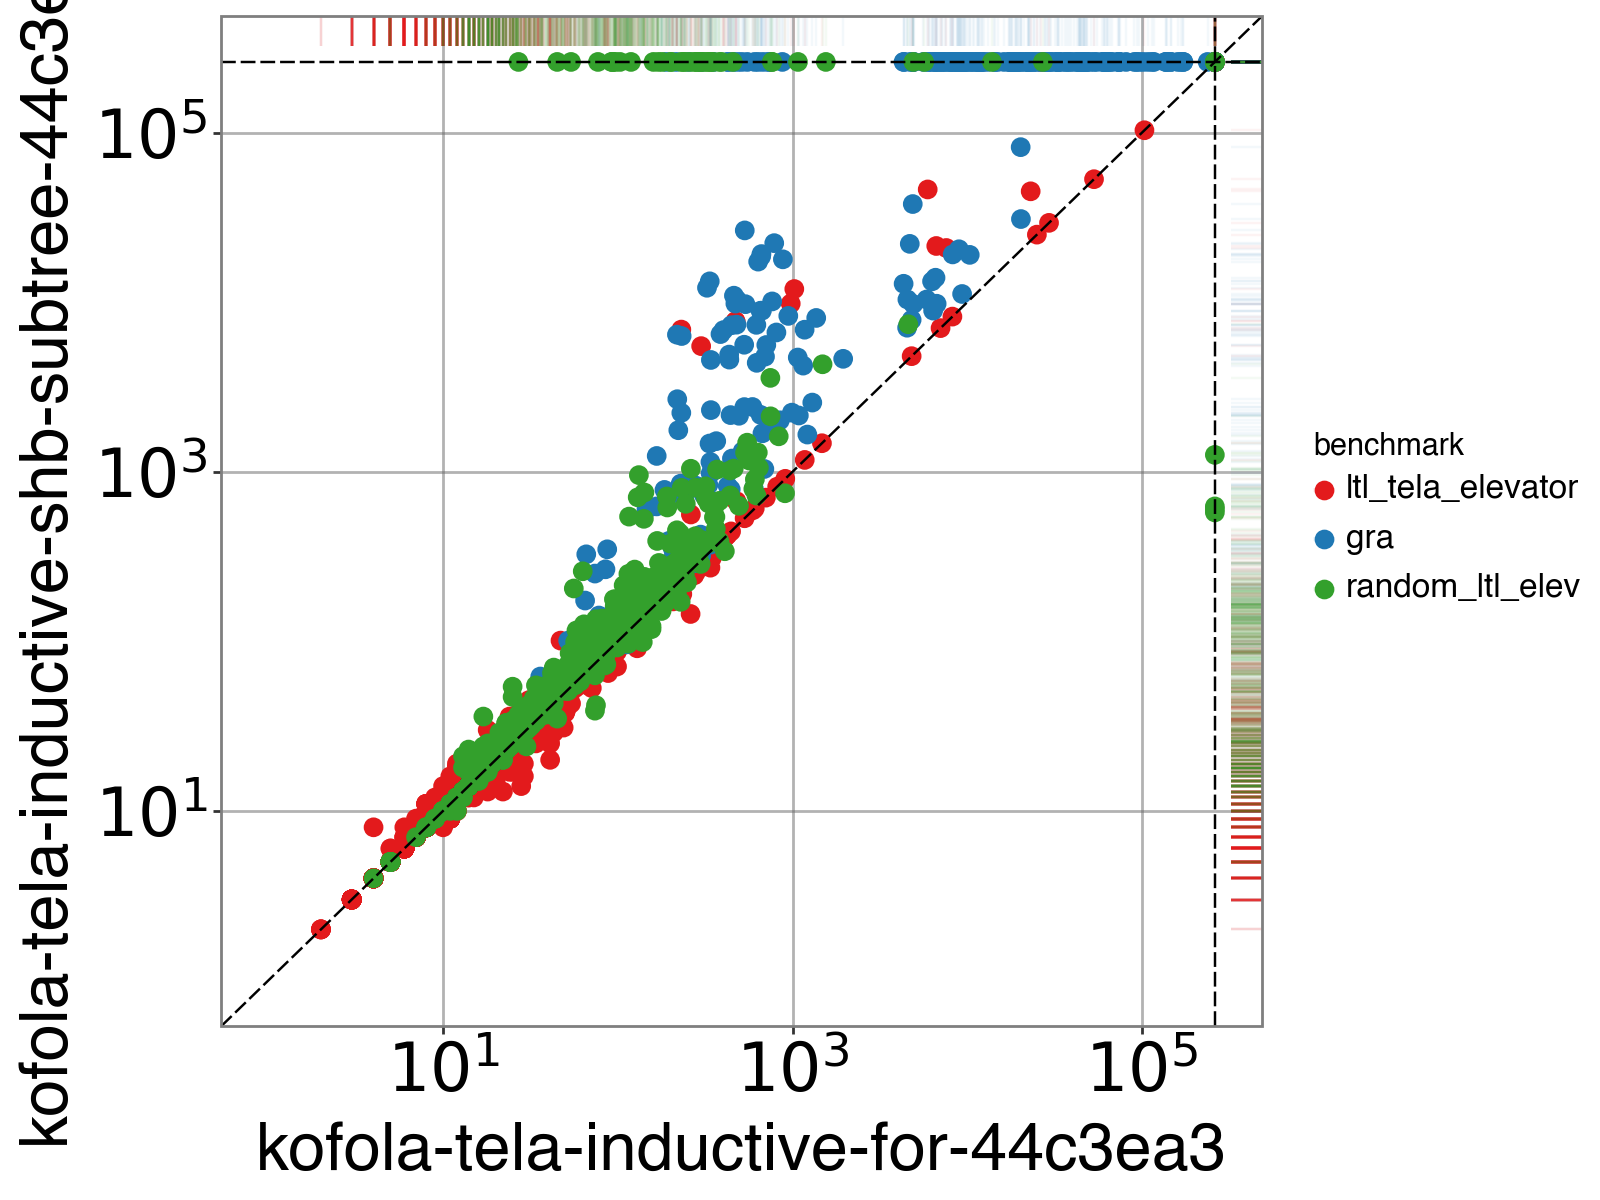

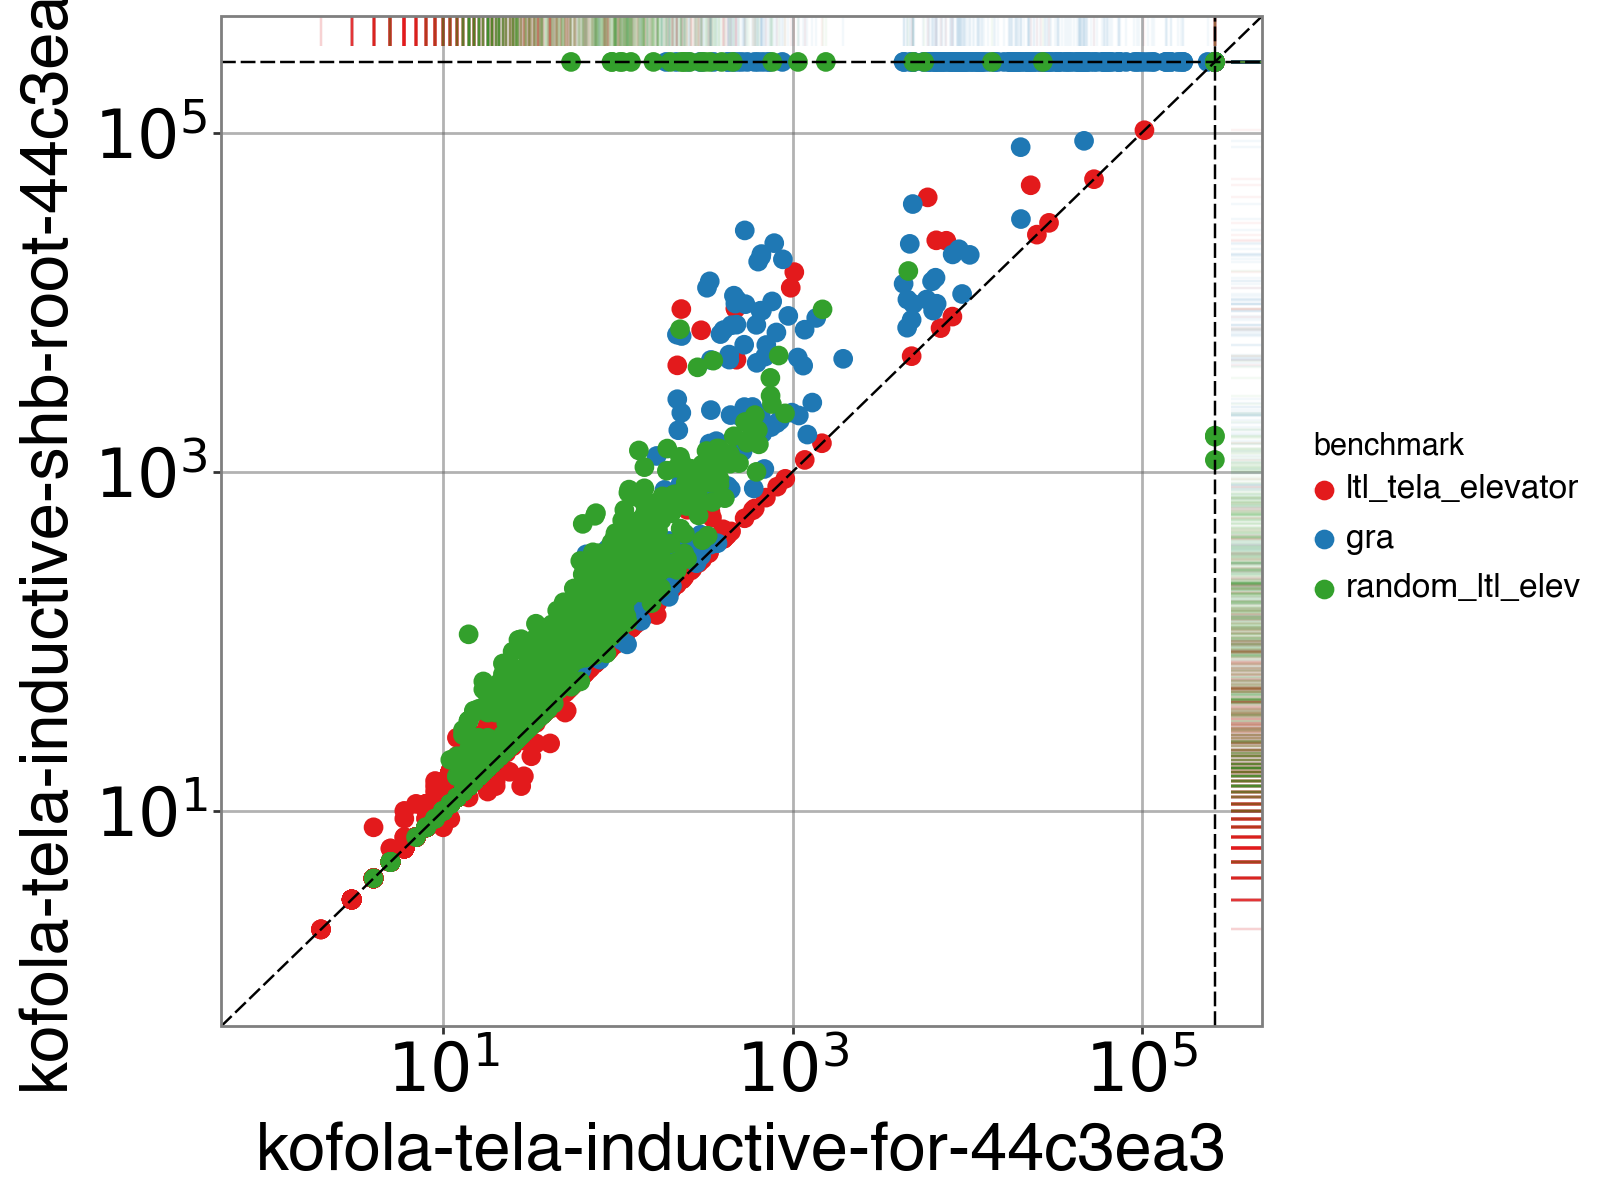

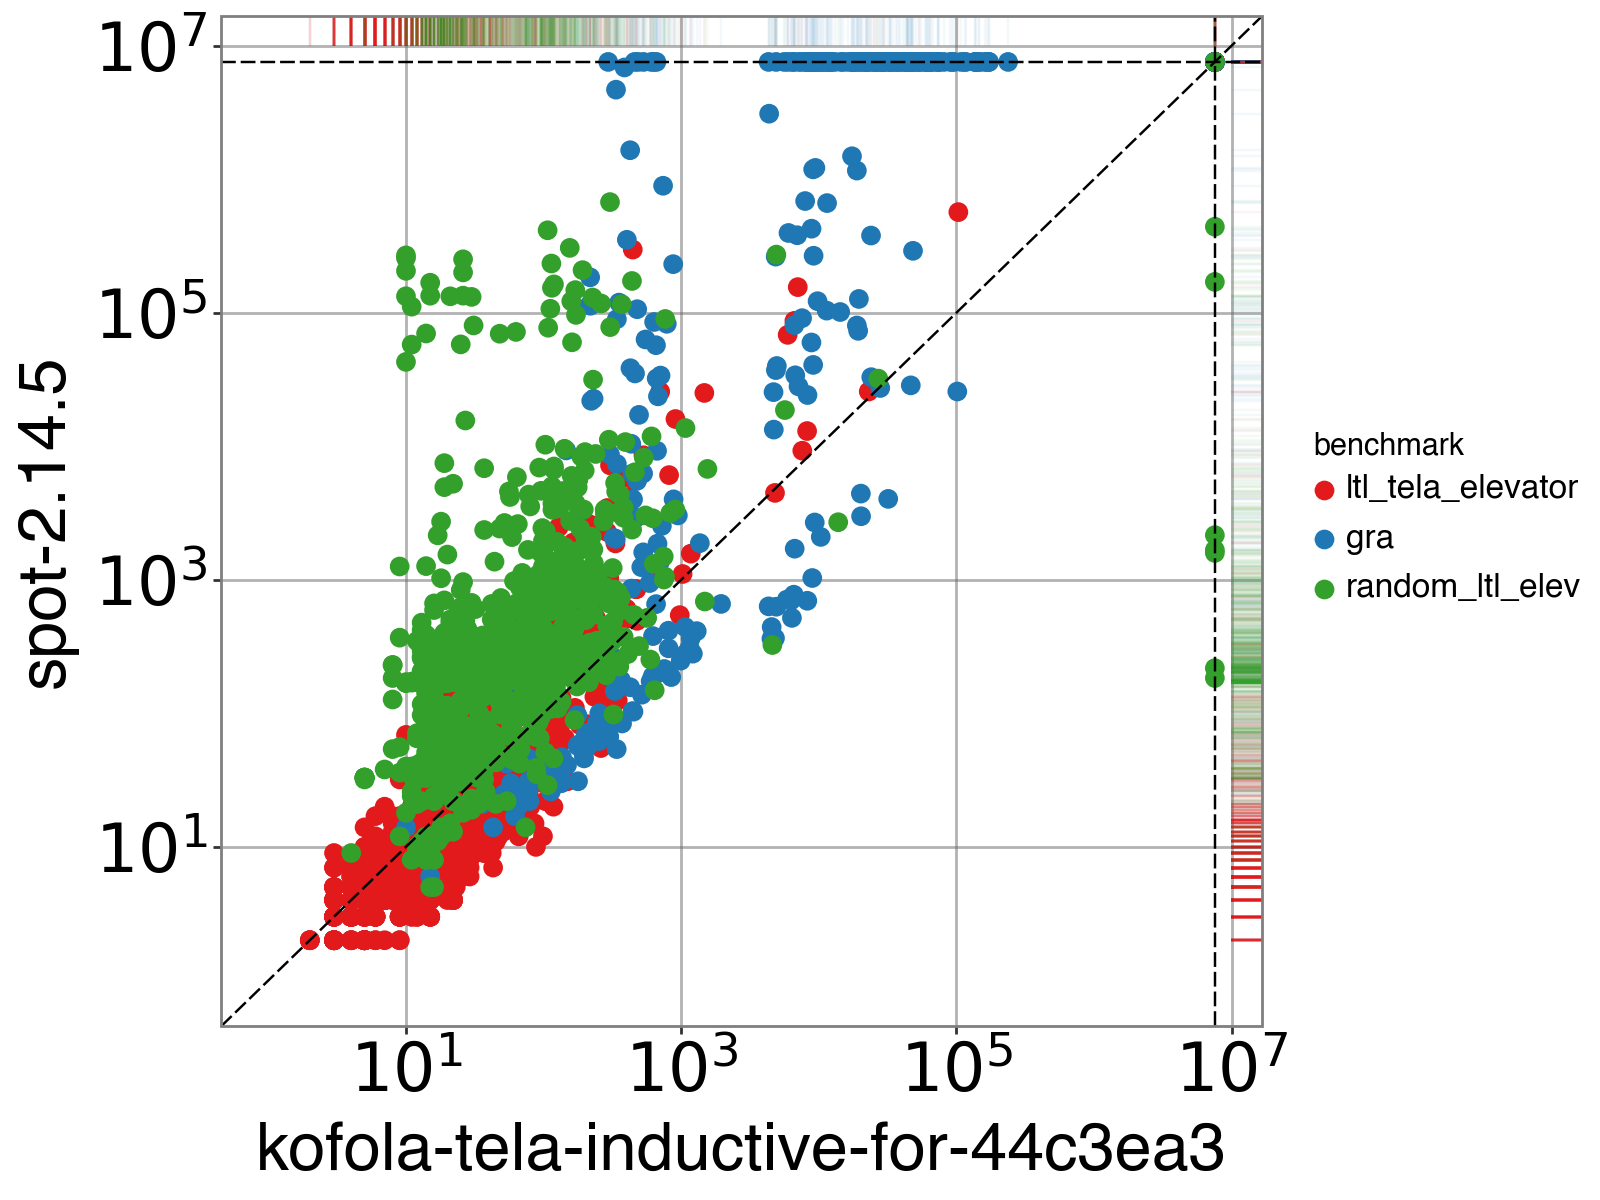

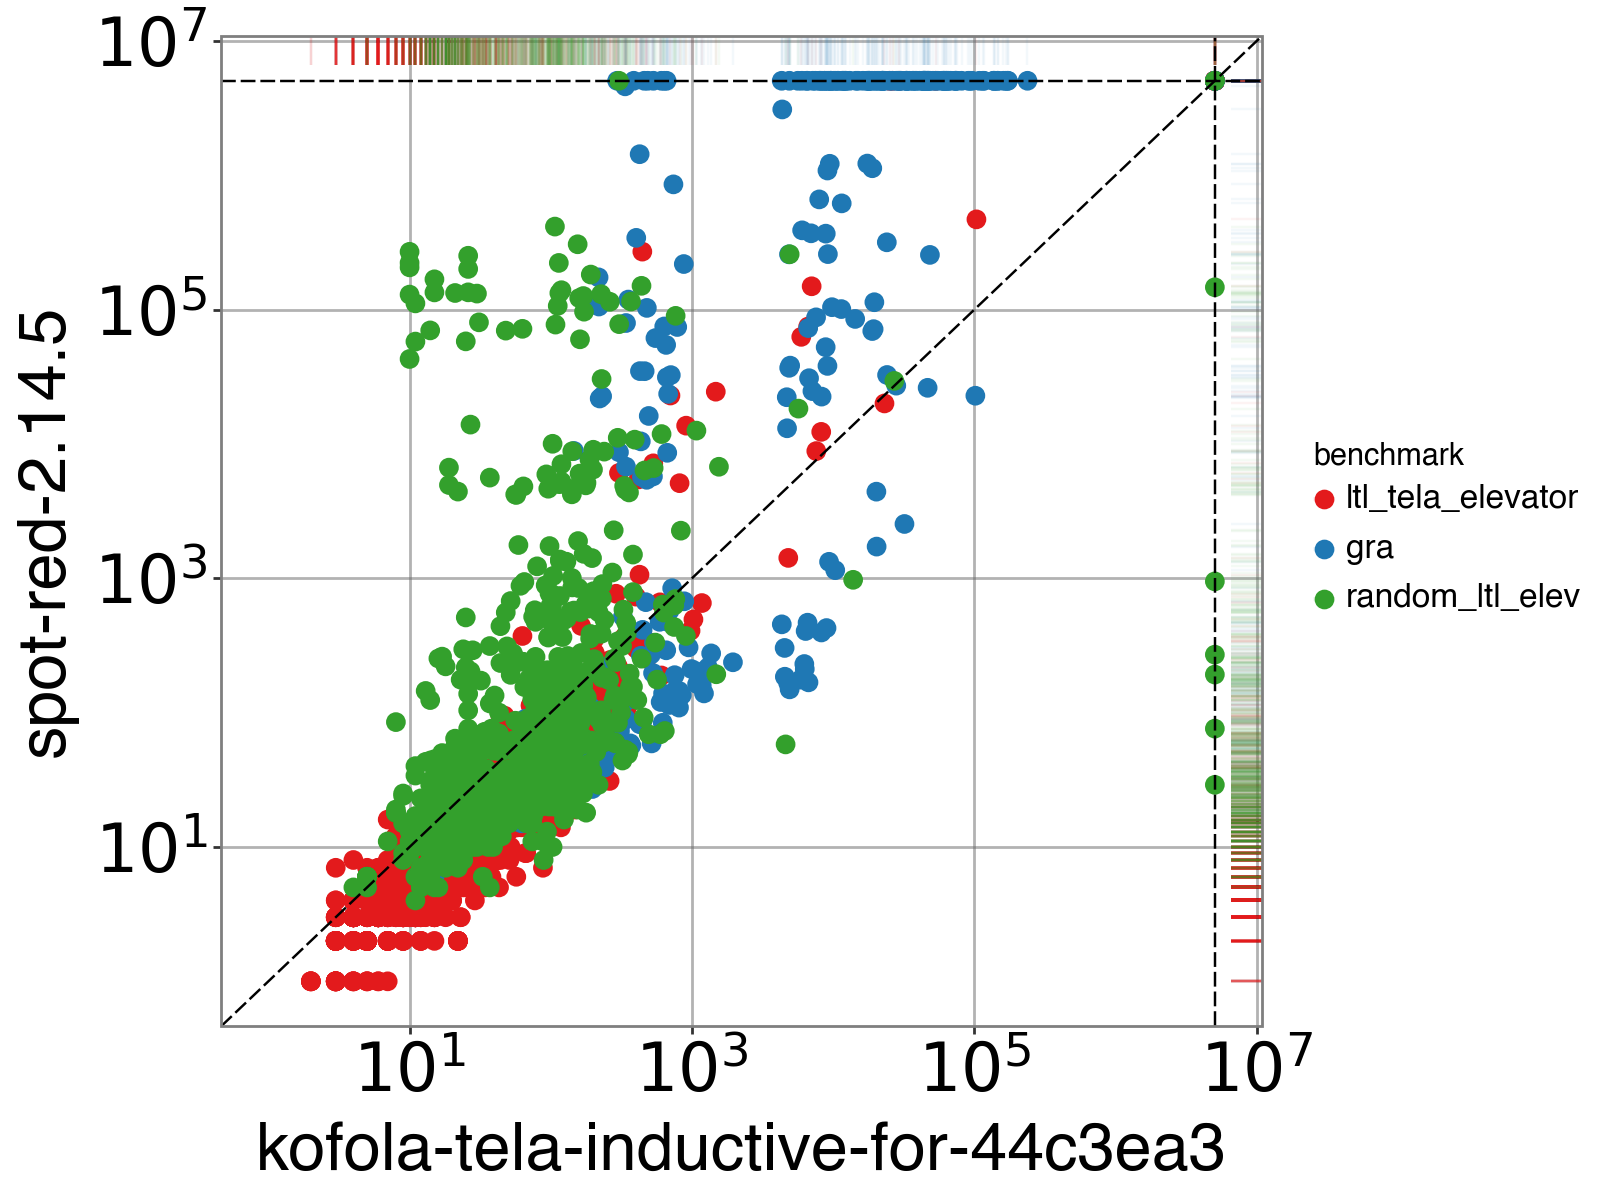

In [73]:
for tool in TOOLS:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot_states(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", clamp=False, legend_name_map={"advanced_automata_termination":"termination", "elevator_generalized_rabin_pair_tela":"gra", "random_ltl_elevators":"random_ltl_elev"}))

### Time

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


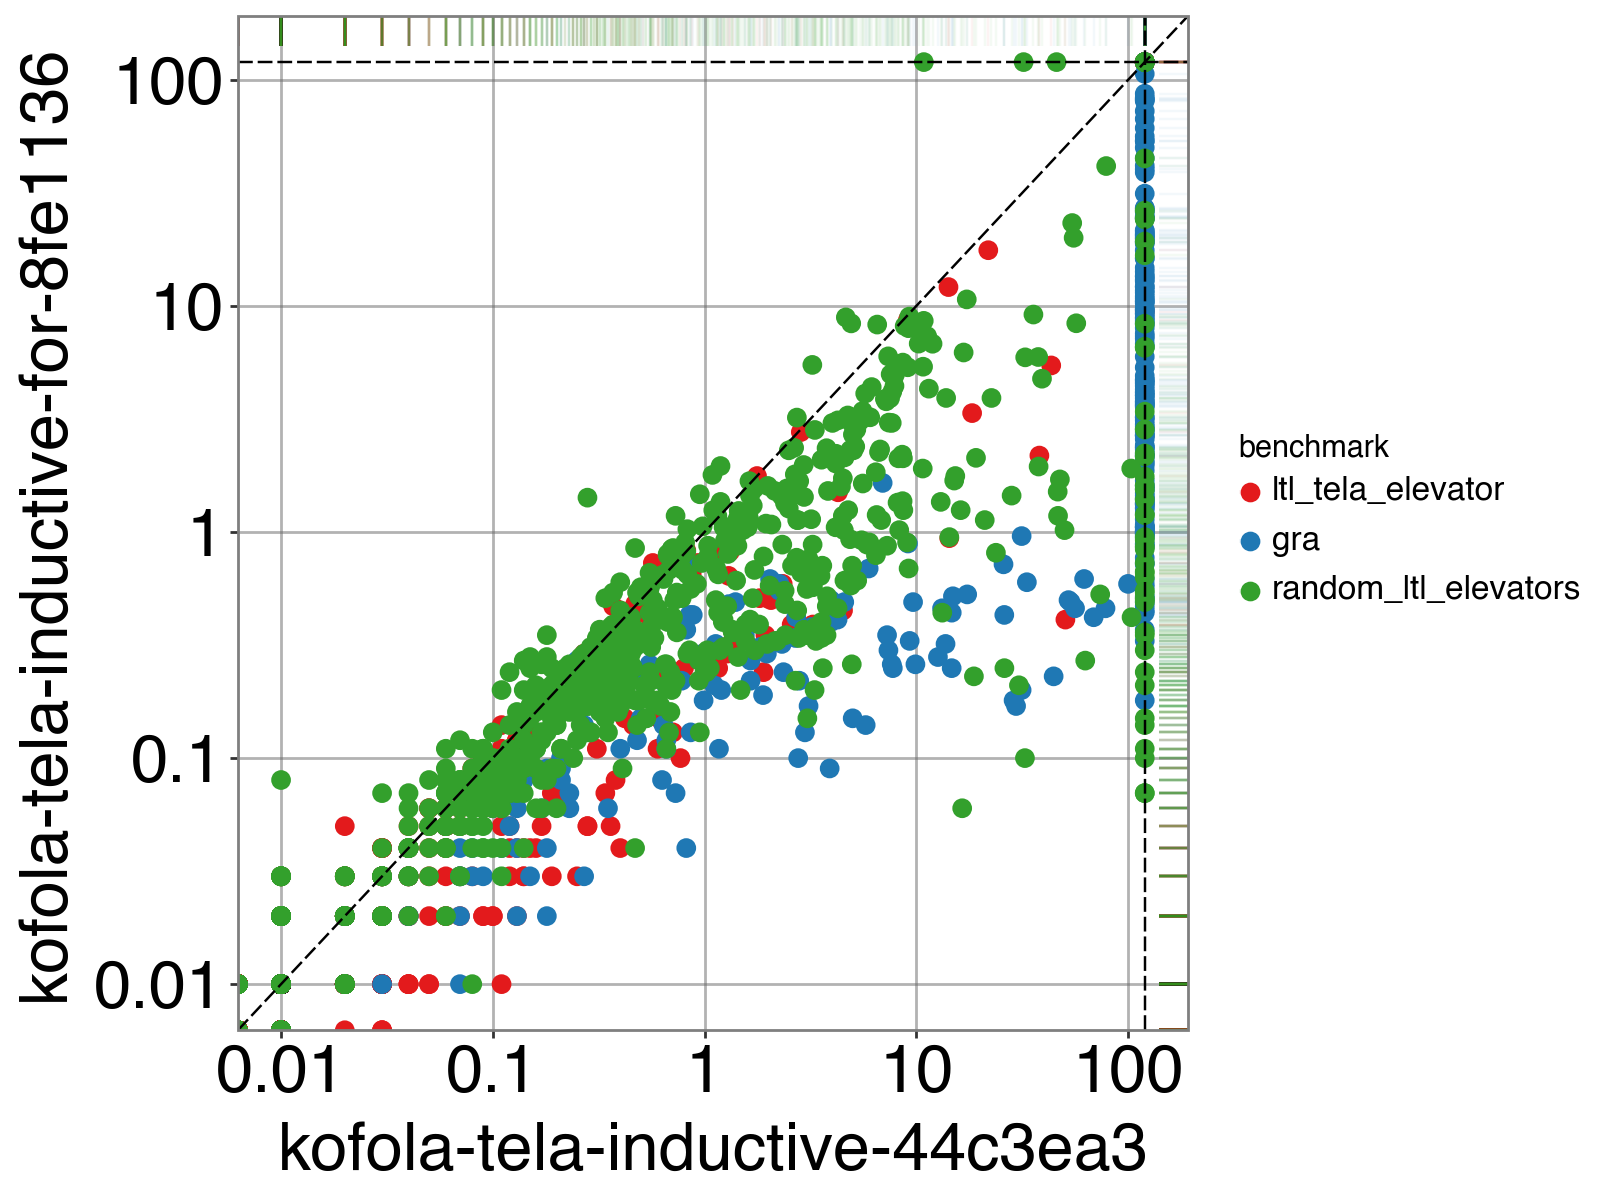

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


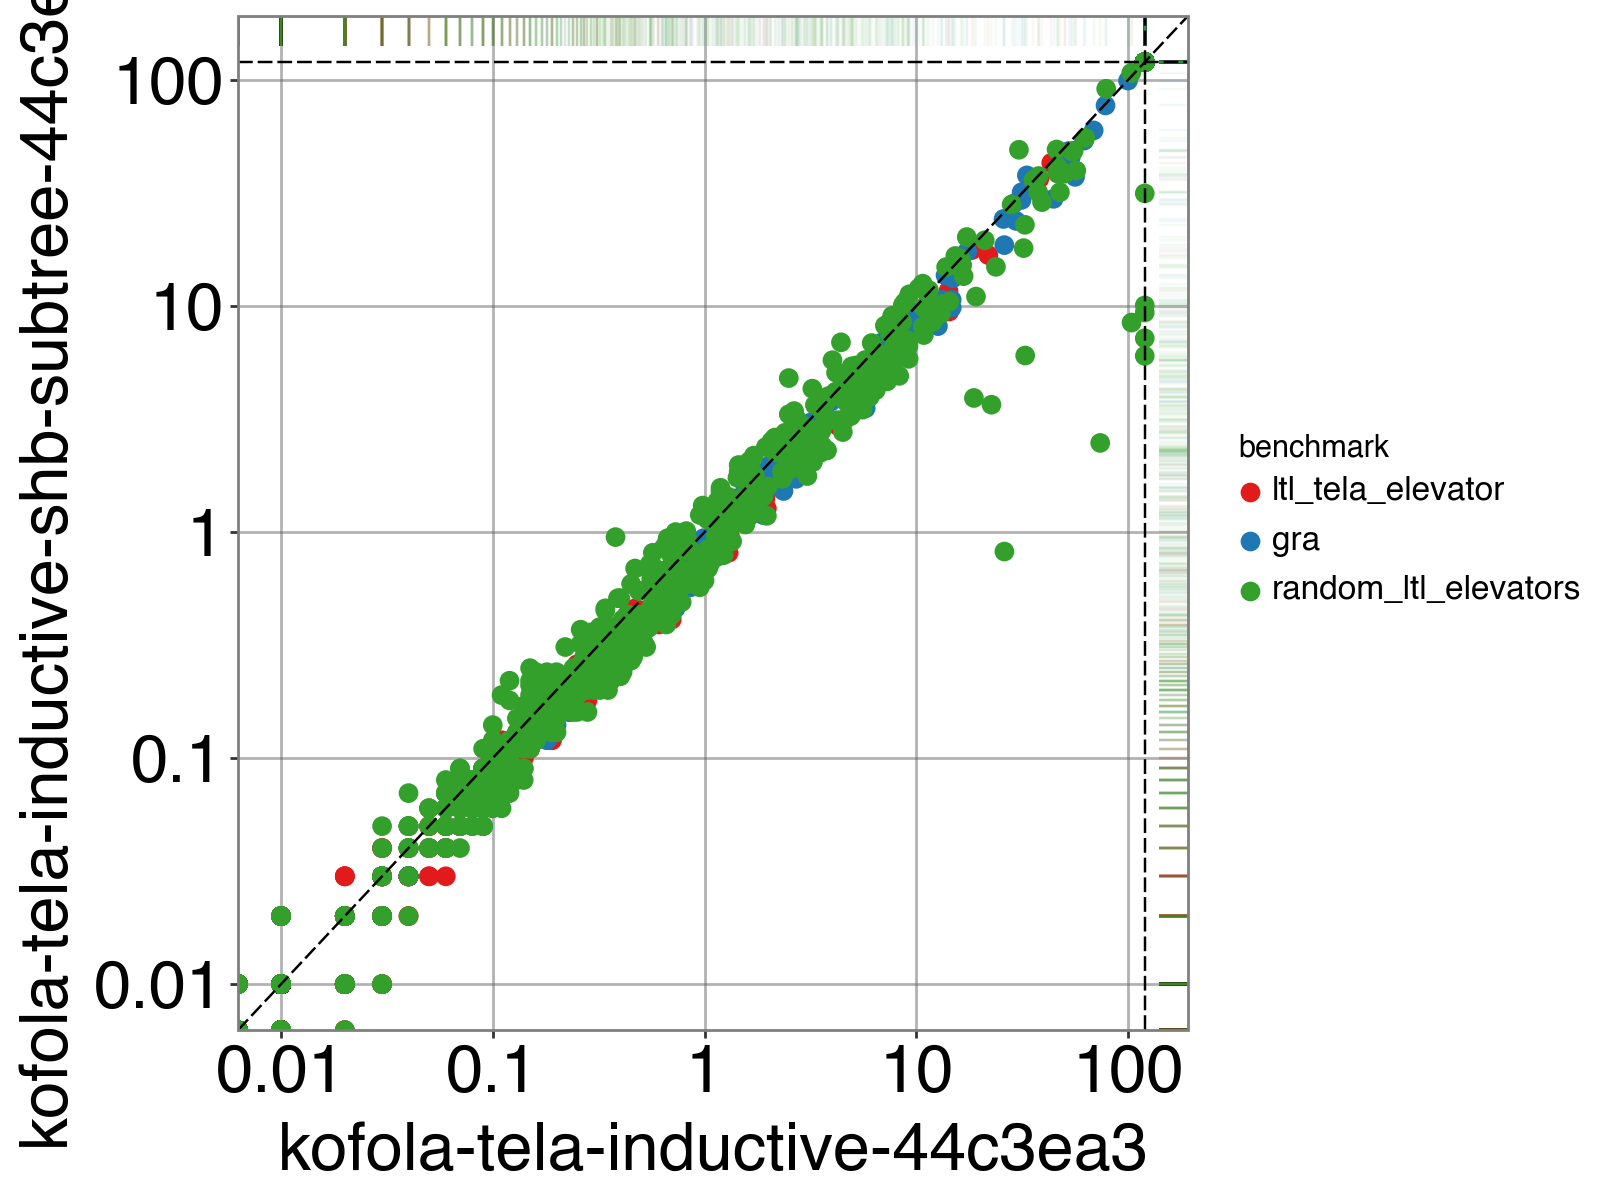

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


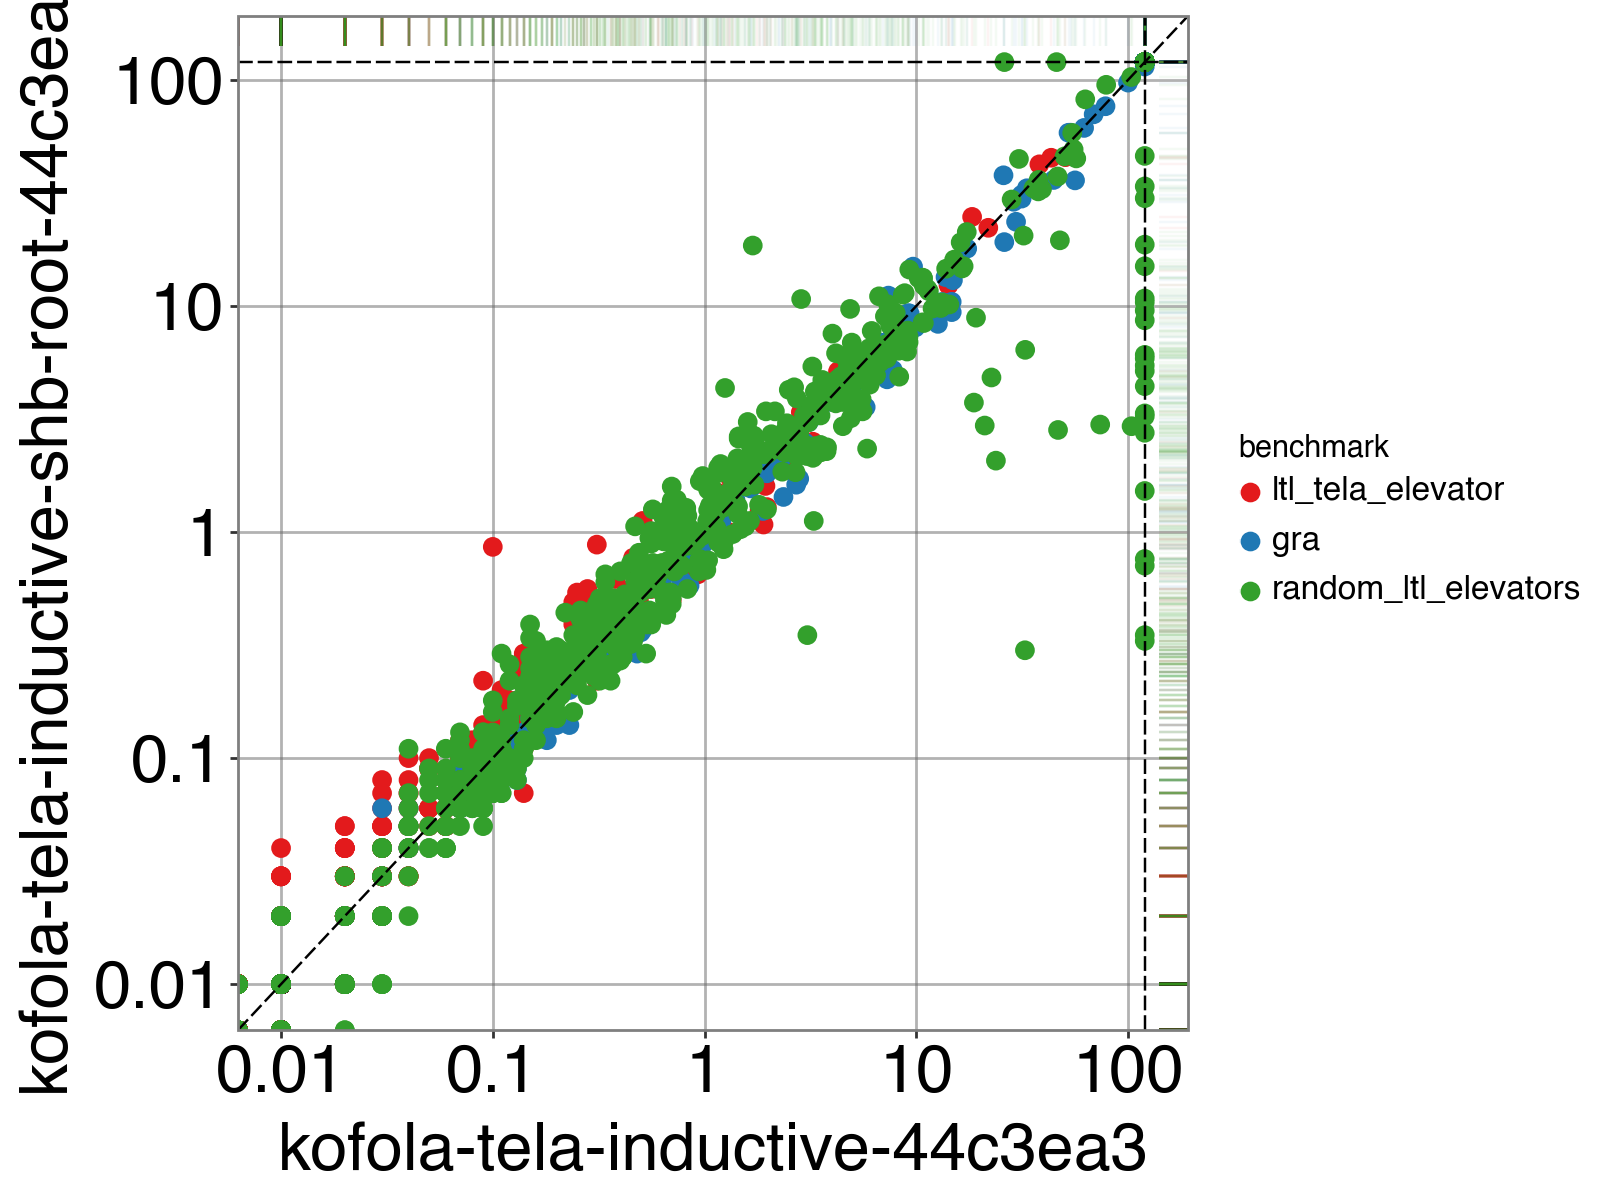

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


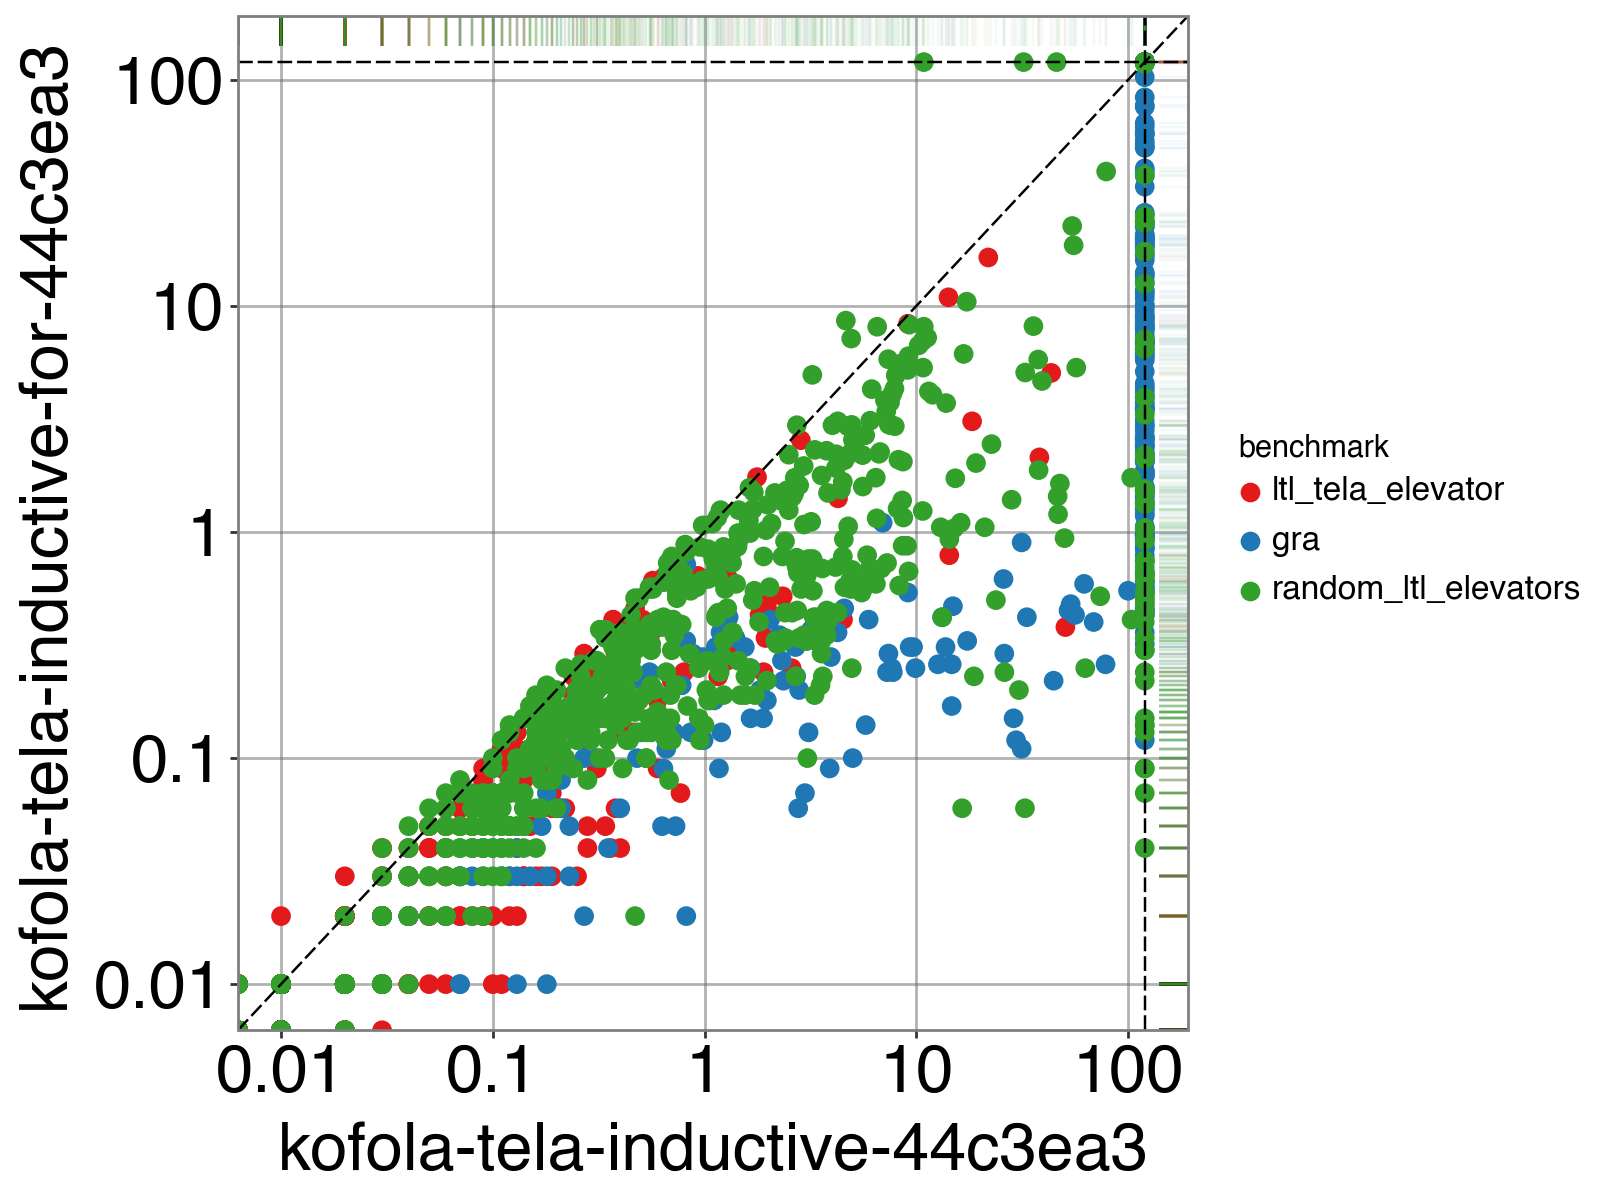

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


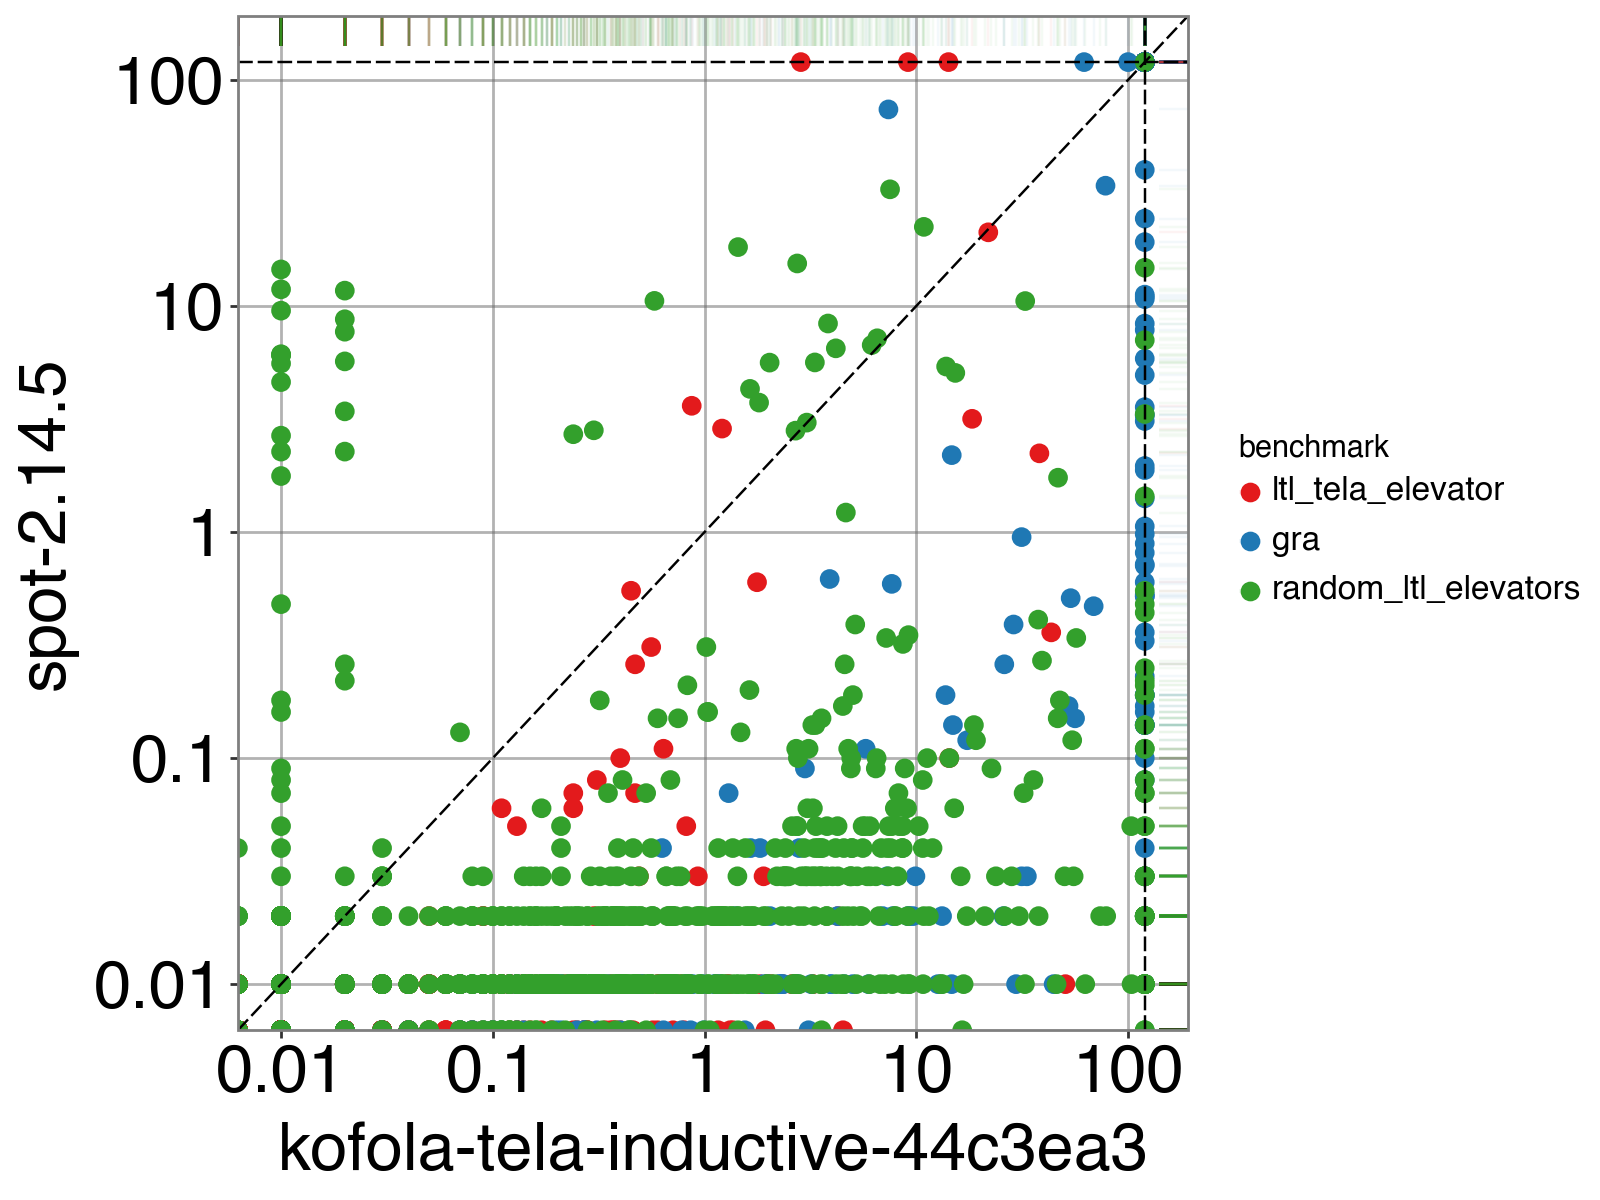

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


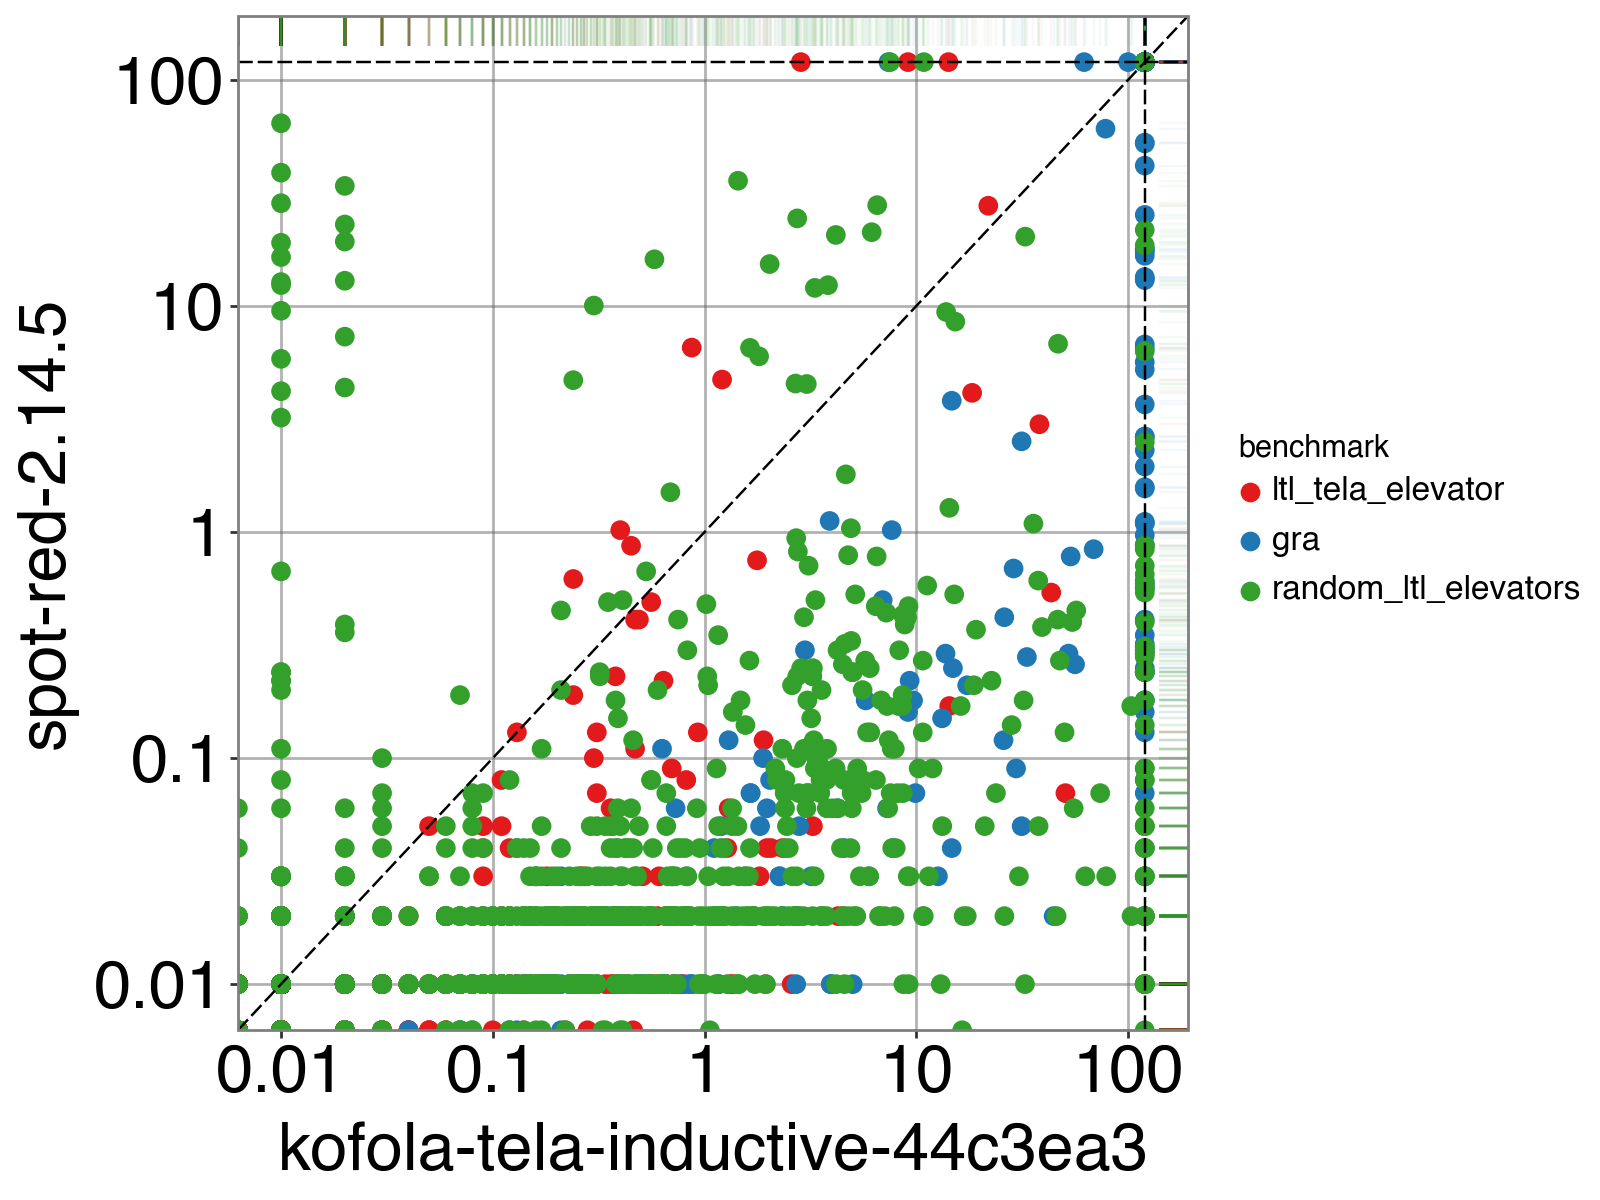

In [70]:
for tool in TOOLS:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", timeout=TIMEOUT, legend_name_map={"advanced_automata_termination":"termination", "elevator_generalized_rabin_pair_tela":"gra"}))

### More detailed evaluation

In [74]:
get_invalid(df_all, TOOLS_CHECK)

Loading ITables v2.4.4 from the internet... (need help?)


In [38]:
get_errors(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [39]:
get_solved(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [147]:
get_timeouts(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [48]:
col_new = f"cola-cola-states"
col_old = f"{KOFOLA_SIM_PRUNE}-states"

# sanity check
for c in (col_new, col_old):
    if c not in df_all.columns:
        raise KeyError(f"Column {c} not found in df_all")

# normalize values: strip strings, try to parse numbers, otherwise keep string
def _norm(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    try:
        # handle floats that represent integers as well
        v = float(s)
        if v.is_integer():
            return int(v)
        return v
    except Exception:
        return s

comp = df_all[[col_new, col_old, "benchmark", "name"]].copy()
comp["_a"] = comp[col_new].apply(_norm)
comp["_b"] = comp[col_old].apply(_norm)

df_diff_states = comp[comp["_a"] != comp["_b"]].drop(columns=["_a", "_b"])

print(f"Rows where {col_new} differs from {col_old}: {len(df_diff_states)}")
display(df_diff_states)

Rows where cola-cola-states differs from kofola-sim-prune-af70d5f-states: 3898


Loading ITables v2.4.4 from the internet... (need help?)


# LaTeX Tables

In [49]:
BENCHMARK_TO_LATEX = {
    # Benchmark names.
    "seminator": "Seminator",
    "advanced_automata_termination": "Termination",
    "autohyper": "AutoHyper",
    "pecan": "Pecan",
    "s1s": "S1S",
    "state_of_buchi": "State-of-Buchi",
    "ldba4ltl": "LDBA4LTL"
}
TOOLS_PAPER = list(dict.fromkeys([
    KOFOLA,
    SPOT,
    KOFOLA_TACAS23,
    KOFOLA_SUBS_TUP,
    RANKER,
    COLA
]))
TOOLS_PLOT= list(dict.fromkeys([
    KOFOLA,
    SPOT,
    KOFOLA_TACAS23,
    KOFOLA_SUBS_TUP,
    RANKER,
]))
TOOL_MAP = {
    KOFOLA: "Kofola",
    SPOT: "Spot",
    COLA: "Cola",
    KOFOLA_TACAS23: "KofolaOld",
    KOFOLA_SUBS_TUP: "KofolaSlice",
    RANKER: "Ranker"
}
df_stats = build_complement_stats_df(df_all, TOOLS_PAPER, BENCHES)
cnt = count_unsupported_instances(BENCHES, TOOLS_PAPER, TIMEOUT)
print(cnt)
unsupported = { k: sum(v.values()) for k, v in cnt.items() }
df_unsupported = pd.DataFrame.from_dict(unsupported, orient="index", columns=["unsupported"]).reset_index().rename(columns={"index":"tool"})
display(df_unsupported[["tool", "tool_name", "unsupported"]] if "tool_name" in df_unsupported.columns else df_unsupported)
# join unsupported counts into df_stats and update OOR
df_stats = df_stats.merge(df_unsupported[['tool', 'unsupported']], on='tool', how='left')
df_stats['unsupported'] = df_stats['unsupported'].fillna(0).astype(int)

# subtract unsupported from OOR and ensure non-negative integer
df_stats['OOR'] = (df_stats['OOR'] - df_stats['unsupported']).clip(lower=0).astype(int)
df_stats

{'kofola-c729572': {'advanced_automata_termination': 0, 'autohyper': 0, 'pecan': 0, 's1s': 0, 'state_of_buchi': 0, 'seminator': 0, 'ldba4ltl': 0}, 'spot-2.14.2': {'advanced_automata_termination': 0, 'autohyper': 0, 'pecan': 0, 's1s': 0, 'state_of_buchi': 0, 'seminator': 0, 'ldba4ltl': 0}, 'kofola-tacas23-tacas23': {'advanced_automata_termination': 0, 'autohyper': 0, 'pecan': 0, 's1s': 0, 'state_of_buchi': 0, 'seminator': 0, 'ldba4ltl': 0}, 'kofola-subs-tup-c729572': {'advanced_automata_termination': 0, 'autohyper': 0, 'pecan': 0, 's1s': 0, 'state_of_buchi': 0, 'seminator': 0, 'ldba4ltl': 0}, 'ranker-ranker': {'advanced_automata_termination': 0, 'autohyper': 0, 'pecan': 1336, 's1s': 0, 'state_of_buchi': 0, 'seminator': 0, 'ldba4ltl': 0}, 'cola-cola': {'advanced_automata_termination': 0, 'autohyper': 0, 'pecan': 247, 's1s': 0, 'state_of_buchi': 0, 'seminator': 0, 'ldba4ltl': 0}}


Loading ITables v2.4.4 from the internet... (need help?)


Loading ITables v2.4.4 from the internet... (need help?)


In [50]:
print(complement_stats_to_latex(df_stats))

\begin{tabular}{lrllllrr}
\toprule
 & solved & total & max & avg & med & OOR & unsupported \\
tool &  &  &  &  &  &  &  \\
\midrule
kofola-c729572 & 31273 & 2477966 & 394220.00 & 79.24 & 2.00 & 0 & 0 \\
spot-2.14.2 & 31271 & 3607908 & 406339.00 & 115.38 & 2.00 & 2 & 0 \\
kofola-tacas23-tacas23 & 31229 & 1334775 & 67835.00 & 42.74 & 2.00 & 44 & 0 \\
kofola-subs-tup-c729572 & 31269 & 5191493 & 762302.00 & 166.03 & 2.00 & 4 & 0 \\
ranker-ranker & 29494 & 1350817 & 25369.00 & 45.80 & 2.00 & 443 & 1336 \\
cola-cola & 31026 & 1762428 & 185644.00 & 56.80 & 2.00 & 0 & 247 \\
\bottomrule
\end{tabular}



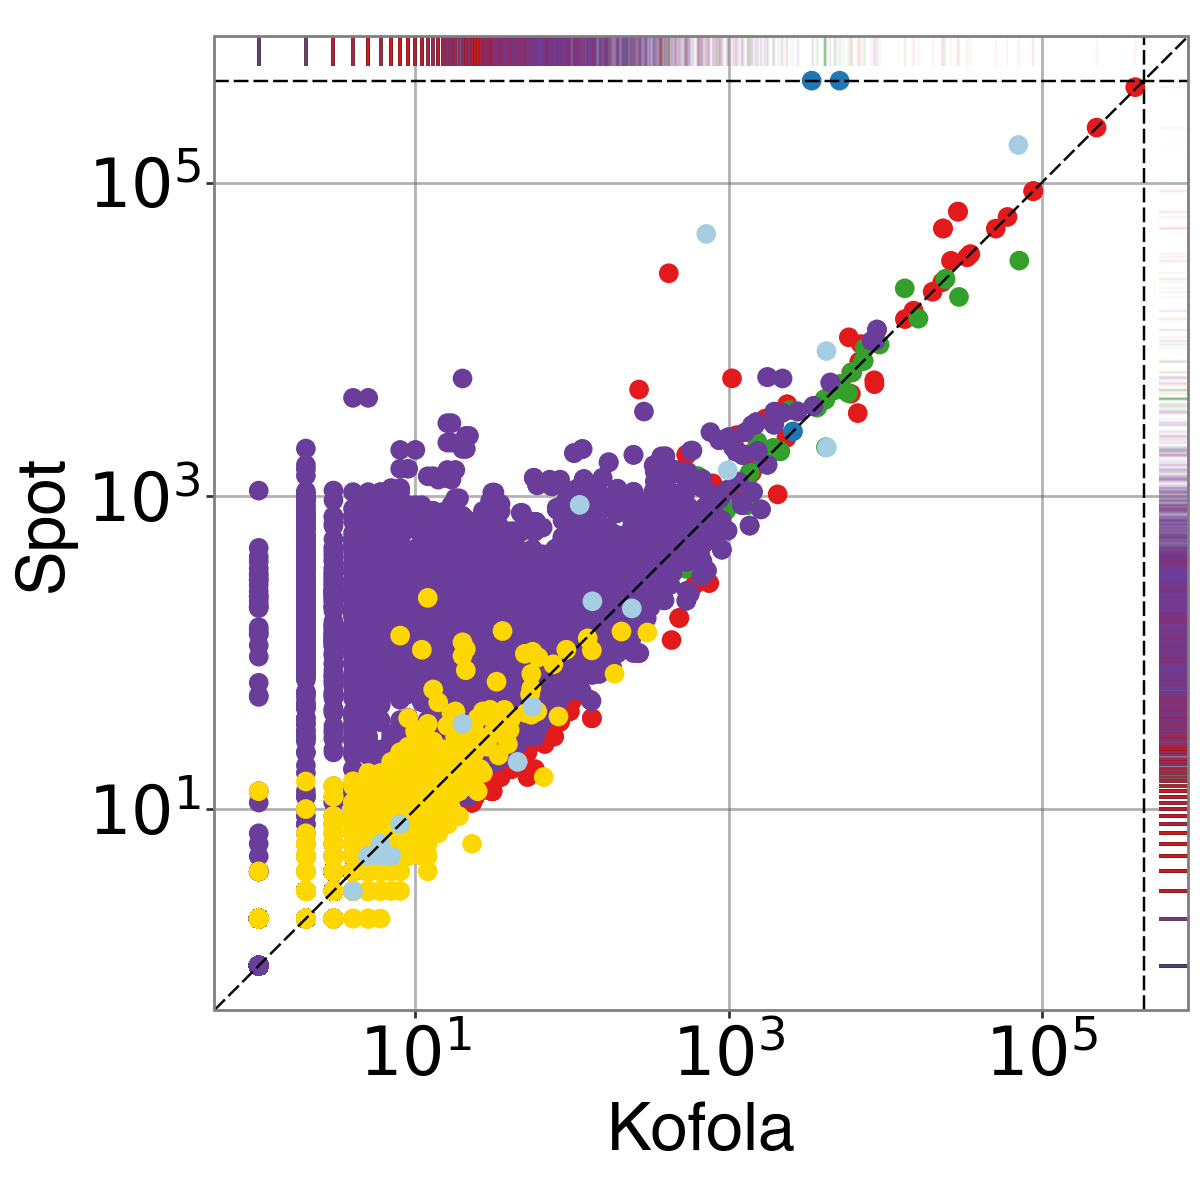

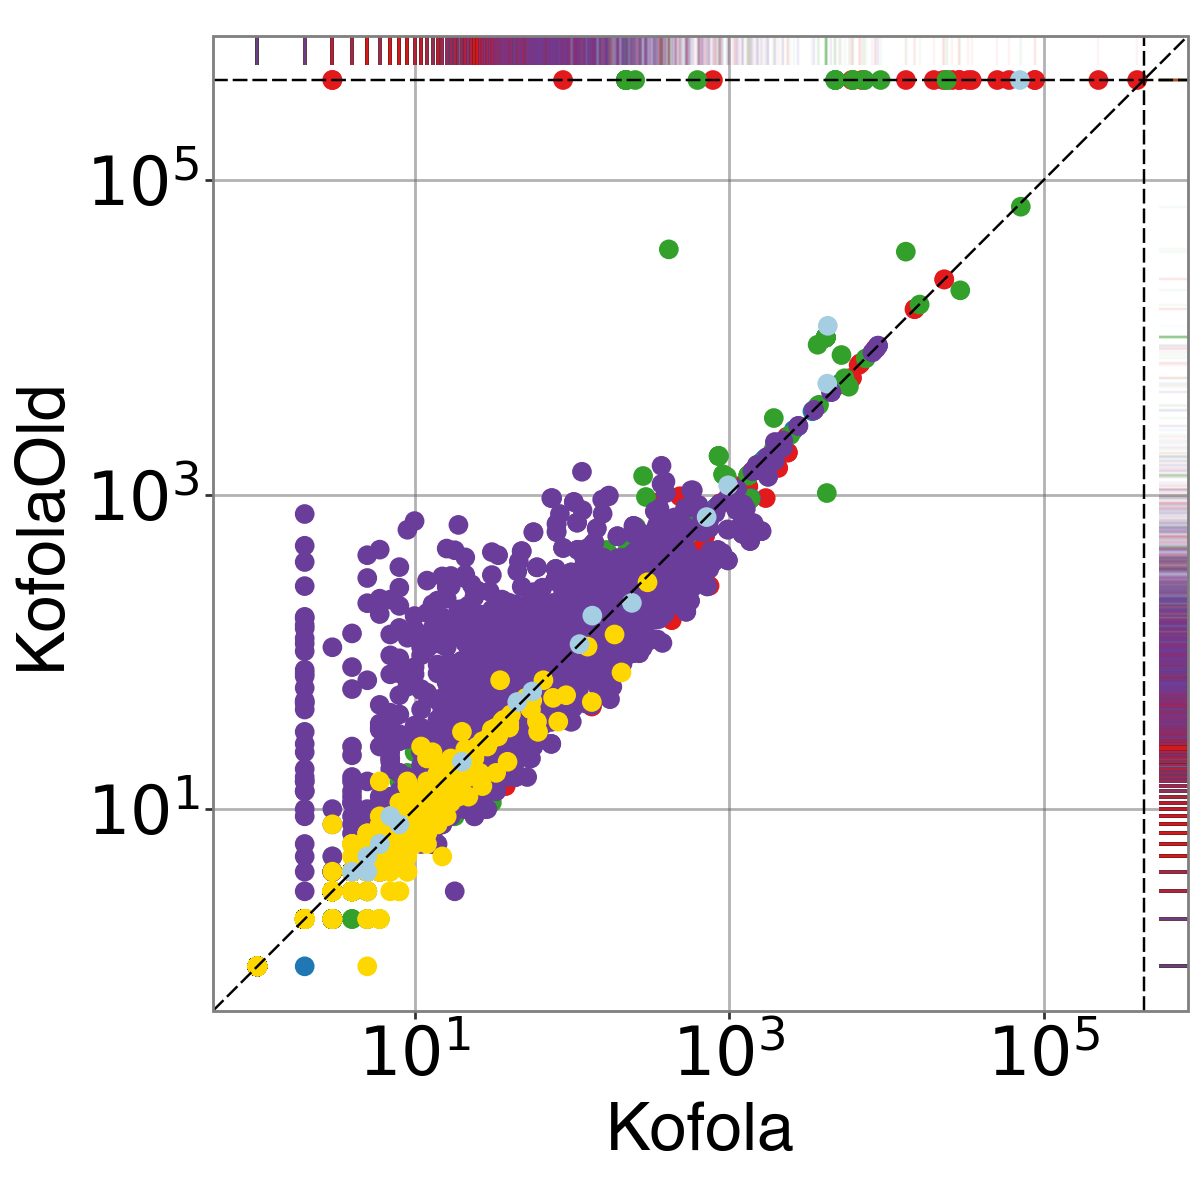

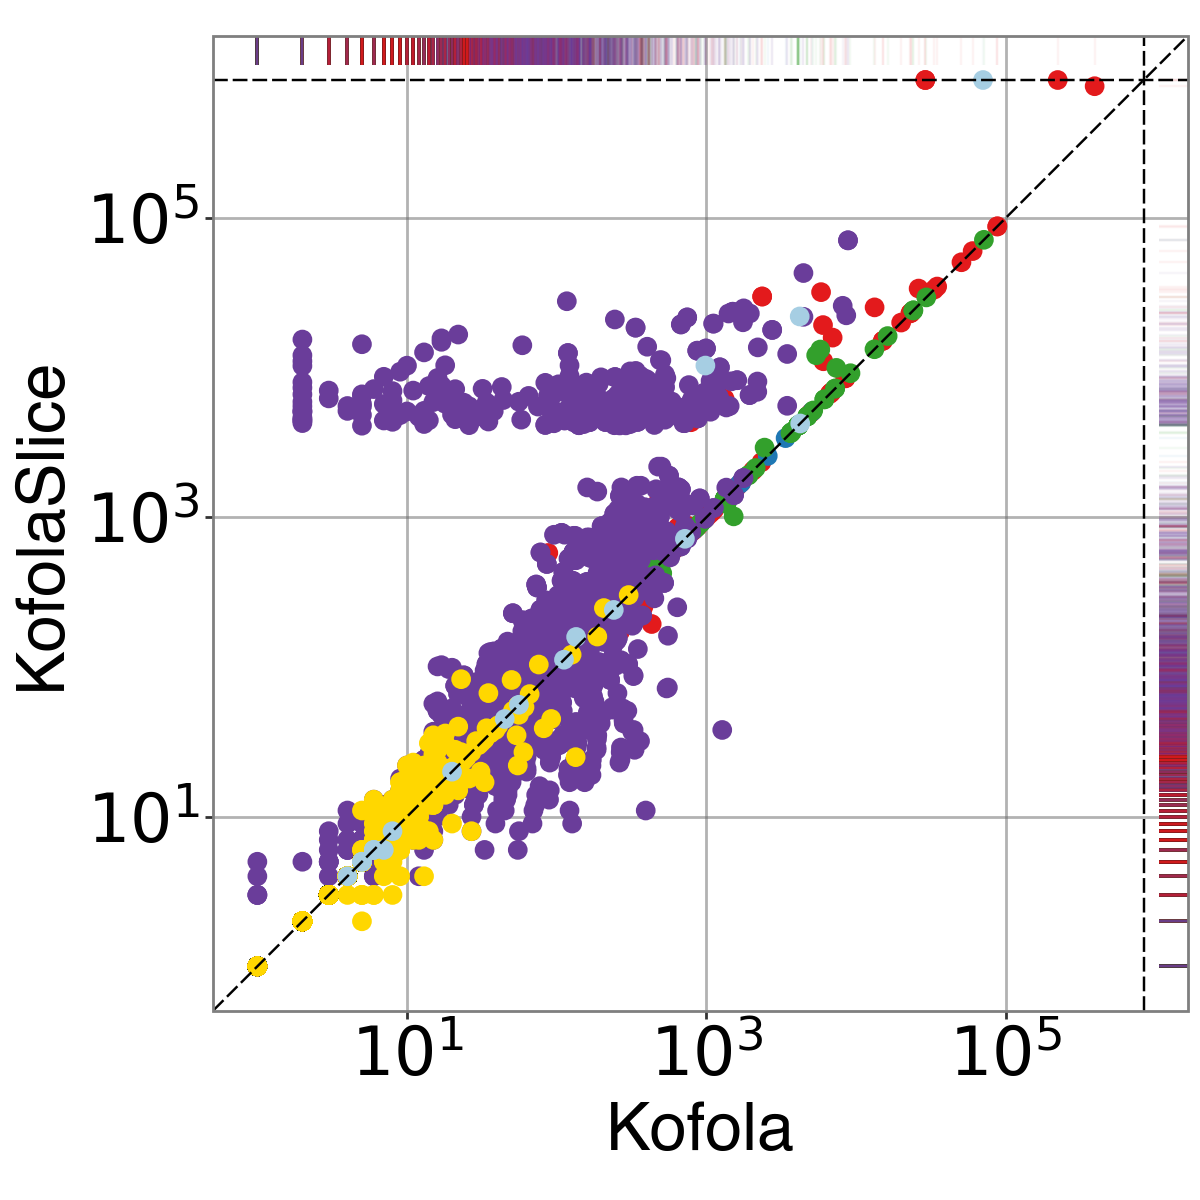

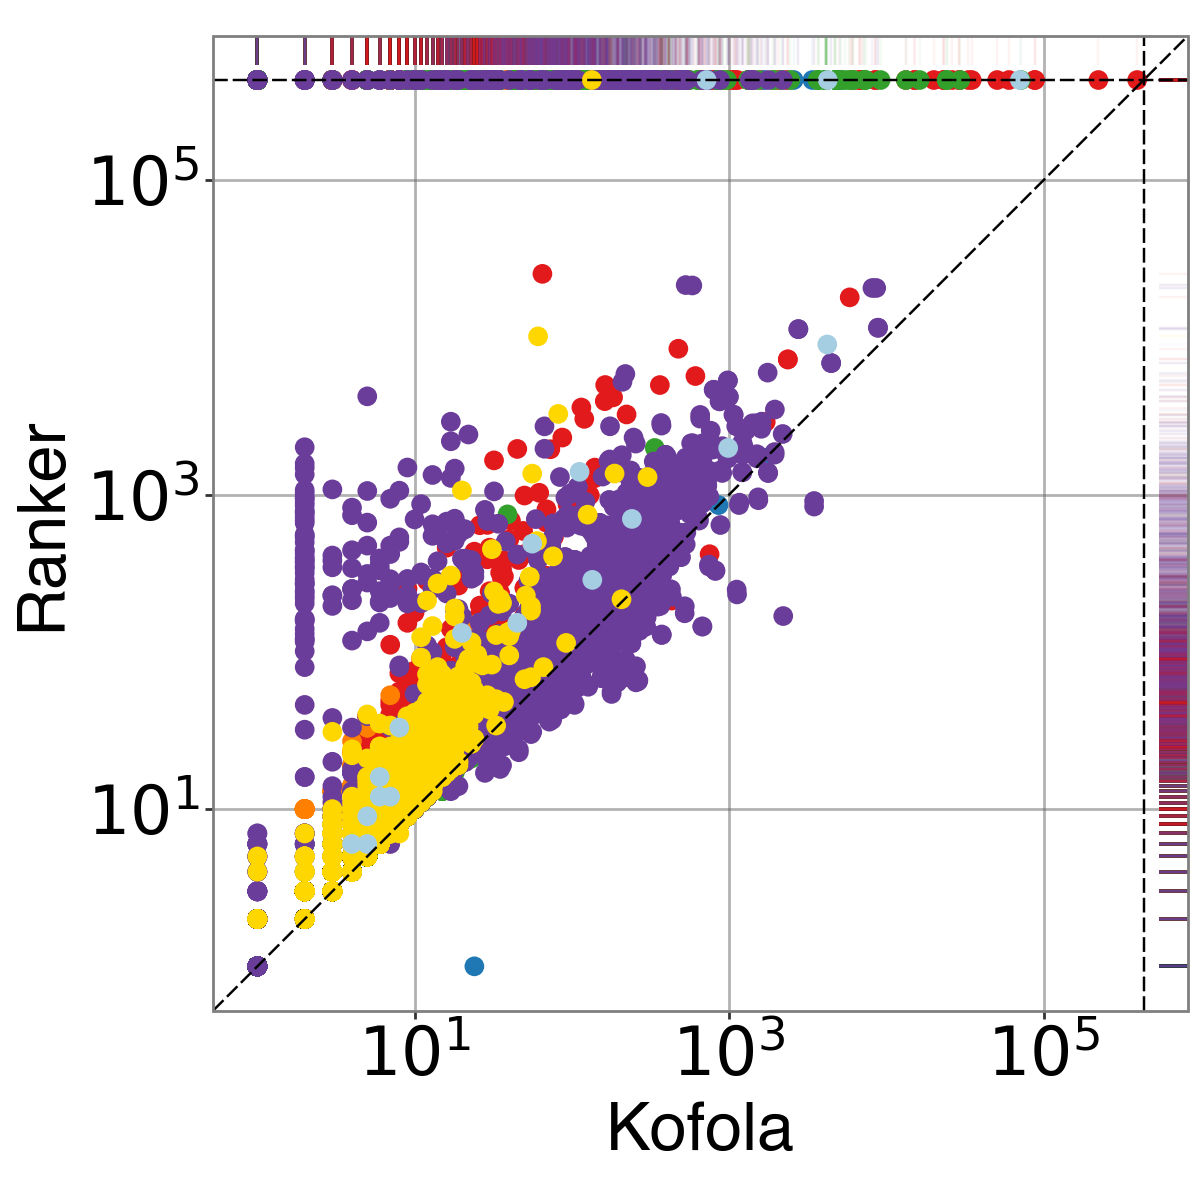

In [51]:
for tool in TOOLS_PLOT:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot_states(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", legend_name_map=BENCHMARK_TO_LATEX, tool_name_map=TOOL_MAP, show_legend=False, file_name_to_save=f"compl_{TOOL_FOR_COMPARISON}_{tool}"))